# CVE to CWE Mapping

## Pre reqs:
You need to have ran scrape_cwe.ipynb file and fill the CVE folder in scrapers/scraped_data in order to continue

### Requirements

In [ ]:
%pip install torch torchvision --index-url https://download.pytorch.org/whl/cpu 
%pip install sentence-transformers pandas tqdm matplotlib

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://download.pytorch.org/whl/cpu
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.3/196.3 MB 10.9 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 15.2 MB/s eta 0:00:00
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
Using cached https://download.pytorch.org/whl/jinja2-3.1.6-py3-none-any.whl (134 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━ 5/7 [torch]^C]
ERROR: Operation cancelled by user
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━ 5/7 [torch]
Note: you may need

In [1]:
import json
import re
 
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer

/home/regularpooria/Projects/CWE_CVE_Mapping/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Loading scraped data

In [3]:
# !git clone https://github.com/regularpooria/CWE_CVE_Mapping # Kaggle
# BASE_DIR = "./CWE_CVE_Mapping" # Kaggle
BASE_DIR = "../" # Local

### Loading CWE

In [4]:
with open(f"{BASE_DIR}/scrapers/scraped_data/CWE_SOFTWARE.json", "r", encoding="utf-8") as f:
    CWE = json.load(f)

### Loading CVE

In [5]:
child_to_cats = {}
for cat_id, category in CWE.items():
    for child_id in category["children"].keys():
        child_to_cats.setdefault(child_id, []).append(cat_id)
 
# %%
CVE_files = ["nvd_2025_cwe699.csv"]
CVE = pd.concat(
    [pd.read_csv(f"{BASE_DIR}/scrapers/scraped_data/CVE/{file}") for file in CVE_files],
    ignore_index=True,
)
 
if CVE["description"].isna().any():
    raise ValueError("Some descriptions in CVE are empty, please check and remove")
 

## Ground Truth

In [6]:
def parse_ids(value):
    return re.findall(r"\d+", str(value))
 
 
CVE["true_children"] = CVE["cwe_699_matches"].apply(
    lambda v: [c for c in parse_ids(v) if c in child_to_cats]
)
if (CVE["true_children"].str.len() == 0).any():
    raise ValueError("Some CVEs have a cwe_699_matches value that isn't a known CWE-699 child")
 
CVE["true_categories"] = CVE["true_children"].apply(
    lambda cs: sorted({cat for c in cs for cat in child_to_cats[c]})
)

## Embedding

In [7]:
device = "cuda" if torch.cuda.is_available() else "cpu"
 
model = AutoModelForSequenceClassification.from_pretrained("mulliken/cwe-predictor").to(device)
tokenizer = AutoTokenizer.from_pretrained("mulliken/cwe-predictor")
model.eval()

# Model label -> numeric CWE id string ("CWE-79" -> "79")
label_ids = []
for i in range(model.config.num_labels):
    found = parse_ids(model.config.id2label[i])
    label_ids.append(found[-1] if found else None)
print("Example labels:", [model.config.id2label[i] for i in range(3)], "->", label_ids[:3])
 
# Optional: ignore classes that aren't CWE-699 children, so the model only chooses
# among the same candidates the hierarchical approach can return.
RESTRICT_TO_699 = False
allowed = torch.tensor(
    [(lid in child_to_cats) if RESTRICT_TO_699 else True for lid in label_ids], device=device
)

W1002 12:03:56.620000 79051 site-packages/torch/utils/_pytree.py:630] <enum 'KernelPreference'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
W1002 12:03:56.685000 79051 site-packages/torch/utils/_pytree.py:630] <enum 'ScaleCalculationMode'> is an Enum subclass and is now natively supported by torch.compile as an opaque value type. Calling register_constant() on Enum subclasses is deprecated and will be an error in a future release.
Loading weights: 100%|██████████| 104/104 [00:00<00:00, 922.85it/s]


Example labels: ['CWE-1', 'CWE-1021', 'CWE-113'] -> ['1', '1021', '113']


In [8]:
@torch.no_grad()
def predict_topk(texts, k=10, batch_size=32, max_length=512):
    """Top-k predicted child ids per text (best first). Batched + length-sorted for speed."""
    order = np.argsort([len(t) for t in texts])
    results = [None] * len(texts)
    k = min(k, int(allowed.sum().item()))
 
    for start in tqdm(range(0, len(texts), batch_size)):
        idx = order[start:start + batch_size]
        enc = tokenizer(
            [texts[i] for i in idx],
            return_tensors="pt", truncation=True, max_length=max_length, padding=True,
        ).to(device)
        logits = model(**enc).logits.float()
        logits[:, ~allowed] = float("-inf")
        top = logits.topk(k, dim=-1).indices.cpu().tolist()
        for i, row in zip(idx, top):
            results[i] = [label_ids[j] for j in row]
    return results

In [9]:
CVE["top_children_flat"] = predict_topk(CVE["description"].tolist(), k=10)
 
# Categories implied by the ranked children (first occurrence order, de-duplicated)
def categories_from_children(children):
    seen, out = set(), []
    for c in children:
        for cat in child_to_cats.get(c, []):
            if cat not in seen:
                seen.add(cat)
                out.append(cat)
    return out

100%|██████████| 838/838 [20:12<00:00,  1.45s/it]


In [10]:
CVE["top_categories_flat"] = CVE["top_children_flat"].apply(categories_from_children)
CVE.head(5)
 

,cve_id,published,last_modified,published_year,description,all_nvd_cwes,cwe_699_matches,number_of_nvd_cwes,number_of_cwe_699_matches,true_children,true_categories,top_children_flat,top_categories_flat
0,CVE-2025-0168,2025-01-01T14:15:23.590,2026-06-17T08:26:00.070,2025,A vulnerability classified as critical has bee...,CWE-74|CWE-89,CWE-89,2,1,[89],[137],"[89, 20, 74, 200, 94, 77, 287, 79, 190, 78]","[137, 189]"
1,CVE-2025-22214,2025-01-02T04:15:06.277,2026-06-17T08:45:38.530,2025,Landray EIS 2001 through 2006 allows Message/f...,CWE-89,CWE-89,1,1,[89],[137],"[89, 20, 74, 200, 287, 77, 190, 94, 611, 125]","[137, 189, 19, 1218]"
2,CVE-2025-0171,2025-01-02T15:15:25.550,2026-06-17T08:26:00.413,2025,"A vulnerability, which was classified as criti...",CWE-74|CWE-89,CWE-89,2,1,[89],[137],"[89, 20, 74, 200, 94, 77, 287, 190, 78, 79]","[137, 189]"
3,CVE-2025-0172,2025-01-02T16:15:09.103,2026-06-17T08:26:00.560,2025,A vulnerability has been found in code-project...,CWE-74|CWE-89,CWE-89,2,1,[89],[137],"[89, 20, 74, 200, 94, 287, 77, 190, 78, 79]","[137, 189]"
4,CVE-2025-0173,2025-01-02T18:15:21.630,2026-06-17T08:26:00.697,2025,A vulnerability was found in SourceCodester On...,CWE-74|CWE-89,CWE-89,2,1,[89],[137],"[89, 20, 74, 200, 94, 287, 77, 190, 79, 78]","[137, 189]"


## Predicting CWE category

  k | child recall | category recall
  1 |        0.681 |           0.700
  2 |        0.751 |           0.787
  3 |        0.773 |           0.809
  5 |        0.795 |           0.839
 10 |        0.824 |           0.879


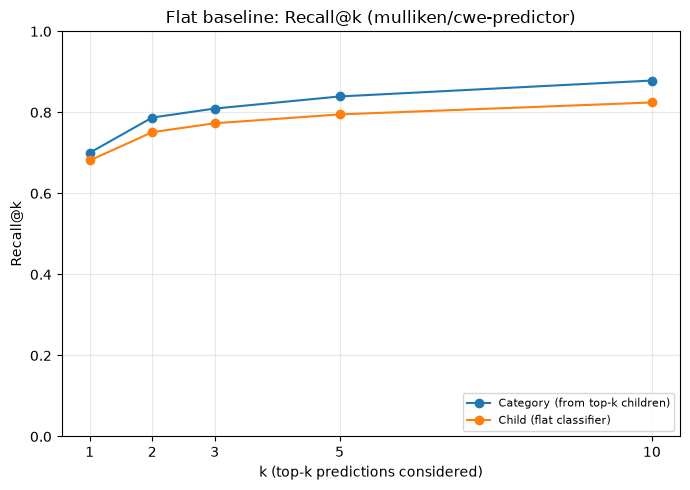

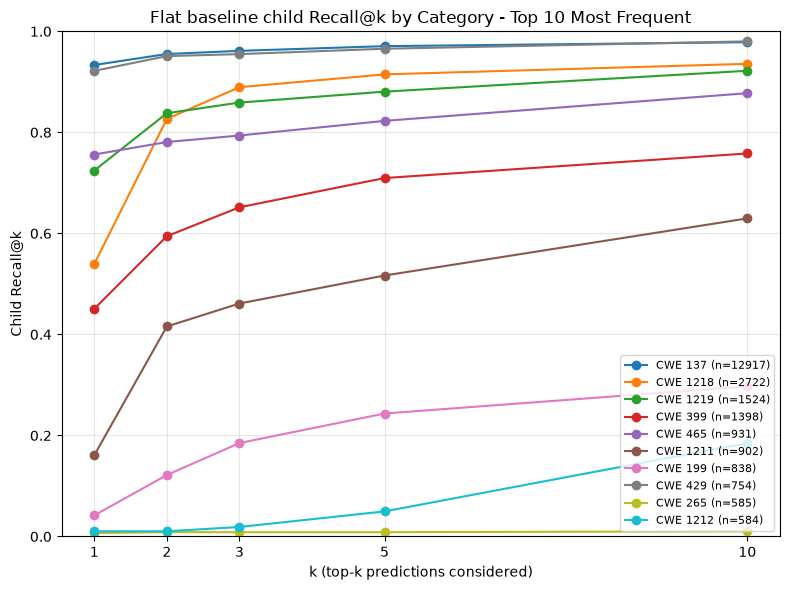

In [11]:

def recall_at_k(truths, predictions, k):
    """Hit if ANY true id is in the top-k predictions."""
    return np.mean([bool(set(t) & set(p[:k])) for t, p in zip(truths, predictions)])
 
 
ks = [1, 2, 3, 5, 10]
 
child_recall = [recall_at_k(CVE["true_children"], CVE["top_children_flat"], k) for k in ks]
# Category recall@k: is a true category among the categories of the top-k predicted children?
cat_recall = [
    recall_at_k(CVE["true_categories"], CVE["top_children_flat"].apply(
        lambda ch, k=k: categories_from_children(ch[:k])), len(CWE))
    for k in ks
]
 
print(f"{'k':>3} | {'child recall':>12} | {'category recall':>15}")
for k, c, a in zip(ks, child_recall, cat_recall):
    print(f"{k:>3} | {c:>12.3f} | {a:>15.3f}")
 
# %%
plt.figure(figsize=(7, 5))
plt.plot(ks, cat_recall, marker="o", label="Category (from top-k children)")
plt.plot(ks, child_recall, marker="o", label="Child (flat classifier)")
plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (top-k predictions considered)")
plt.ylabel("Recall@k")
plt.title("Flat baseline: Recall@k (mulliken/cwe-predictor)")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
 
# %%
# Per-category child recall@1 / @5 for the 10 most frequent categories
CVE["primary_category"] = CVE["true_categories"].str[0]
top_cats = CVE["primary_category"].value_counts().head(10).index.tolist()
 
plt.figure(figsize=(8, 6))
for cat in top_cats:
    s = CVE[CVE["primary_category"] == cat]
    plt.plot(ks, [recall_at_k(s["true_children"], s["top_children_flat"], k) for k in ks],
             marker="o", label=f"CWE {cat} (n={len(s)})")
plt.xticks(ks)
plt.ylim(0, 1)
plt.xlabel("k (top-k predictions considered)")
plt.ylabel("Child Recall@k")
plt.title("Flat baseline child Recall@k by Category - Top 10 Most Frequent")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()